# Download dataset

In [ ]:
import os
import kagglehub
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define download path
os.environ["KAGGLEHUB_CACHE"] = "../datasets"

# Download dataset
path = kagglehub.dataset_download("adilshamim8/social-media-addiction-vs-relationships")
csv_file = os.path.join(path, "Students Social Media Addiction.csv")
df = pd.read_csv(csv_file)
print('\ndataset downloaded at ', path)
print('reading file...')

c:\Users\Sixth\Documents\repos\eda-kaggle-dataset\eda.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



dataset downloaded at  ../datasets\datasets\adilshamim8\social-media-addiction-vs-relationships\versions\3
reading file...


# General dataset exploration

In [3]:
print('*'*30)
print('GENERAL DATASET INFORMATION')
print('*'*30)

print('Columns and records count:')
df.info()
df.describe()
print('*'*30)

print('Gender distribution:')
print(df['Gender'].value_counts())
print('*'*30)

print('Age calculations:')
print(f"mean:\t {df['Age'].mean():.1f}")
print('median:\t', df['Age'].median())
print('*'*30)

print('Countries data:')
print('unique count:\t', df['Country'].nunique()) # len(df['Country'].unique())

******************************
GENERAL DATASET INFORMATION
******************************
Columns and records count:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Confli

# Univariate analysis
This section investigates the distribution of individual variables within the dataset.
The following features were selected for inspection:
- Avg_Daily_Usage_Hours
- Sleep_Hours_Per_Night
- Age

## Methodology
Graphs are plotted based on **one feature at a time**, in order to understand its distribution over the dataset. Histograms and boxplots are used to visualize characteristics such as central tendency, dispersion, outliers, noise and errors in the dataset.
Understanding the distribution of features is important because it can determine if the data approximates a normal distribution. Additionally, identifying distribution patterns provides useful context for later correlation analysis.

Distribution of the Avg_Daily_Usage_Hours column


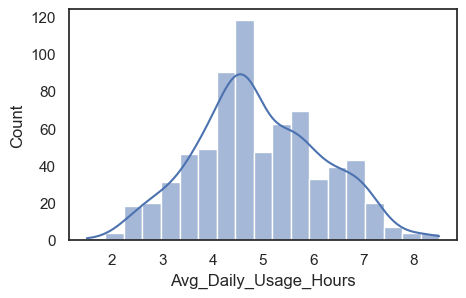

In [145]:
print('Distribution of the Avg_Daily_Usage_Hours column')
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    bins='auto'
)
plt.show()

This plot depicts a histogram highlighting the distribution of the Avg_Daily_Usage_Hours feature.
These results shows an almost ideal normal distribution which can be defined as:
A continuous, symmetric, bell-shaped probability distribution where most data points cluster around a central mean,with frequencies tapering off symmetrically toward the tails.


Distribution of the Sleep_Hours_Per_Night column


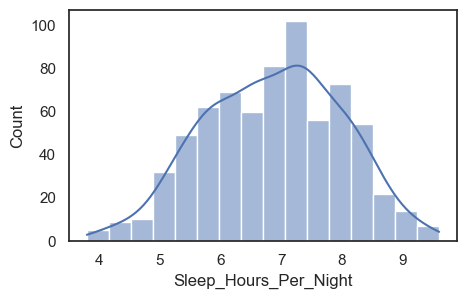

In [146]:
print('Distribution of the Sleep_Hours_Per_Night column')
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Sleep_Hours_Per_Night', 
    kde=True, 
    bins='auto'
)
plt.show()

Similarly, this plot depicts a histogram highlighting the distribution of the Sleep_Hours_Per_Night feature.
The distribution of the values are almost identical to an ideal normal distribution plot.

Distribution of the Age column


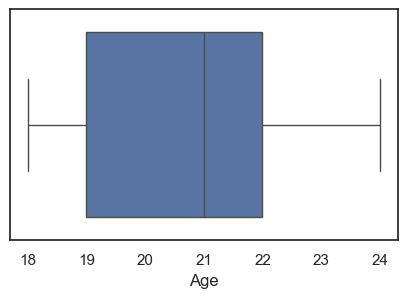

In [147]:
print('Distribution of the Age column')
plt.figure(figsize=(5, 3))
sns.boxplot(data=df, x='Age')
plt.show()

The boxplot suggests a relatively symmetric distribution with no evident outliers, though the exact distribution shape cannot be inferred solely from this visualization.

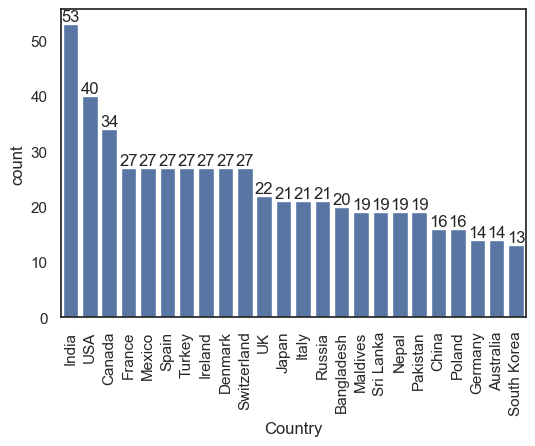

Countries that has ten or more records:  24
Which is only 21.8% of the 110 countries present.


In [148]:

n = 10
top_n = df['Country'].value_counts()[df['Country'].value_counts() > n].index #more than 10 records for simplicity
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    data=df, 
    x='Country',
    order=top_n
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()
print('Countries that has ten or more records: ', len(df['Country'].value_counts()[df['Country'].value_counts() > n].index))
print(f"Which is only {(len(df['Country'].value_counts()[df['Country'].value_counts() > n].index) / df['Country'].nunique()) * 100:.1f}% of the 110 countries present.")

Gender
Female    353
Male      352
Name: count, dtype: int64
['50.1' '49.9']


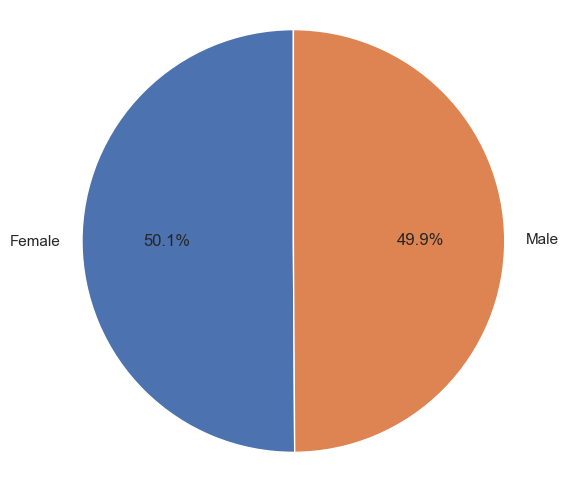

Affects_Academic_Performance
Yes    453
No     252
Name: count, dtype: int64
['64.3' '35.7']


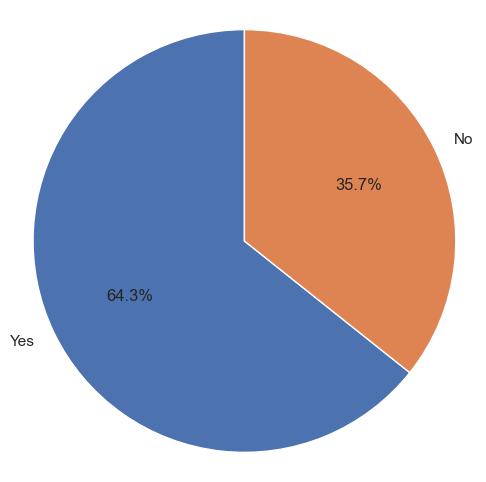

In [ ]:
# import matplotlib.pyplot as plt

print(df['Gender'].value_counts())
normalized_gender_percentages = (df['Gender'].value_counts(normalize=True).mul(100).round(1).astype(float))
print(df['Gender'].value_counts(normalize=True).mul(100).round(1).astype(str).to_numpy())

plt.figure(figsize=(6, 6)) # Optional: set figure size
plt.pie(
    normalized_gender_percentages.to_numpy(),
    labels = ['Female', 'Male'],
    autopct='%1.1f%%',
    startangle=90
)

plt.axis('equal')
plt.show()

print(df['Affects_Academic_Performance'].value_counts())
normalized_gender_percentages = (df['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).astype(float))
print(df['Affects_Academic_Performance'].value_counts(normalize=True).mul(100).round(1).astype(str).to_numpy())

plt.figure(figsize=(6, 6)) # Optional: set figure size
plt.pie(
    normalized_gender_percentages.to_numpy(),
    labels = ['Yes', 'No'],
    autopct='%1.1f%%',
    startangle=90
)

plt.axis('equal')
plt.show()


# Bivariate Analysis

This section presents plots between two features that (potentially) correlate and can present insights not seen before about the data.

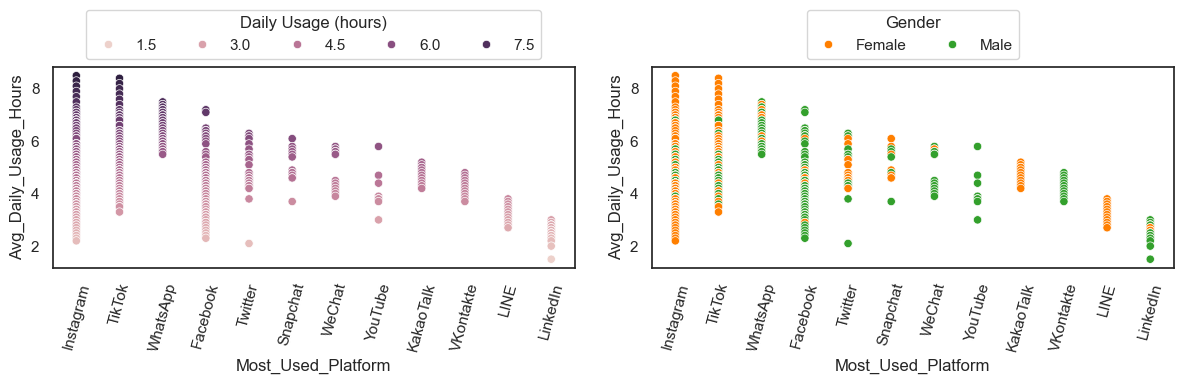

In [ ]:
# import matplotlib.pyplot as plt
# import seaborn as sns

df_sorted = df.sort_values(by="Avg_Daily_Usage_Hours", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12,4))
ax1 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Avg_Daily_Usage_Hours',
    ax=axes[0]
)
axes[0].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax1, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5,
    title='Daily Usage (hours)', frameon=True
)

ax2 = sns.scatterplot(
    data=df_sorted,
    x='Most_Used_Platform',
    y='Avg_Daily_Usage_Hours',
    hue='Gender',
    palette="Paired_r",
    ax=axes[1]
)
axes[1].tick_params(axis='x', rotation=75)
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5,
    title='Gender', frameon=True
)

plt.tight_layout()
plt.show()

Correlation between most used platforms vs. the daily usage shows that the Instagram and Tiktok are the most used platforms at the time of data collecting, it also shows the variety of the time spent by students in these social media applications.
These plots shows the same data under different perspectives, the first dsiplay the time spent by hours, while the latter highlight the gender that uses each platform the most.

## Correlation table
This correlation table between the numerical features emphasizes many strong potential connections that can be correlated to provide more insights and different perspective.

Which can be read like this:
| Correlation (r) | Type |
|-----------------|------|
| 0.90 to 1.00 | Very strong positive |
| 0.70 to 0.89 | Strong positive |
| 0.40 to 0.69 | Moderate positive |
| 0.10 to 0.39 | Weak positive |
| -0.09 to 0.09 | No correlation |
| -0.10 to -0.39 | Weak negative |
| -0.40 to -0.69 | Moderate negative |
| -0.70 to -0.89 | Strong negative |
| -0.90 to -1.00 | Very strong negative |

e.g.: As Avg_Daily_Usage_Hours increases, Sleep_Hours_Per_Night decreases almost perfectly. (WIll be shown later on regresstion plots).

<Figure size 1000x800 with 0 Axes>

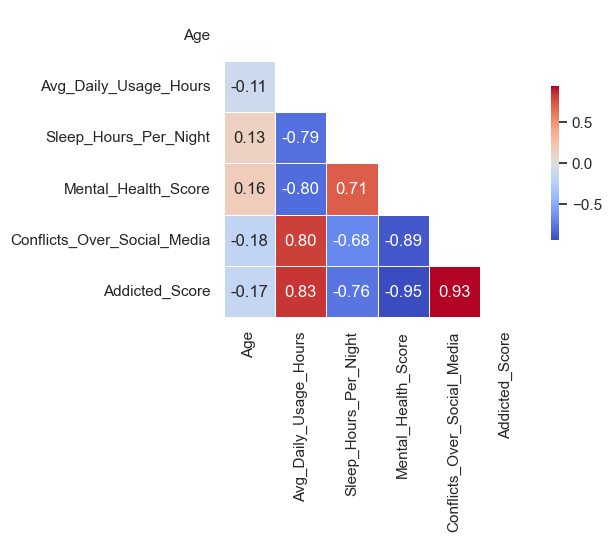

In [163]:
df_numeric = df.select_dtypes(['number'])
df_noIds = df_numeric.drop(columns=['Student_ID'])
corr_matrix = df_noIds.corr()

plt.figure(figsize=(10, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(5, 4))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", square=True,
            linewidths=.5, cbar_kws={"shrink": .5})

plt.show()

How does Avg_Daily_Usage_Hours correlates with other numerical features?

3 good vs. 1 bad correlation


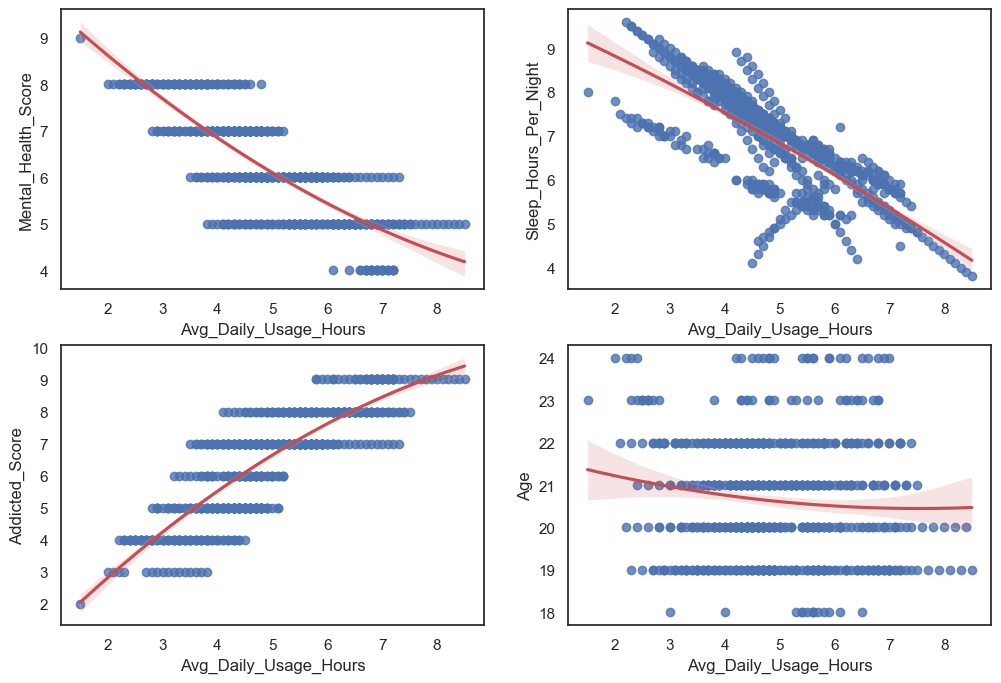

In [ ]:
print('3 good vs. 1 bad correlation')
fig, axes = plt.subplots(2, 2, figsize=(12,8))
ax0 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    order=2,
    ax=axes[0][0],
    line_kws=dict(color="r")
)
ax1 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    order=2,
    ax=axes[0][1],
    line_kws=dict(color="r")
)
ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Addicted_Score',
    order=2,
    ax=axes[1][0],
    line_kws=dict(color="r")
)

ax2 = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Age',
    order=2,
    ax=axes[1][1],
    line_kws=dict(color="r")
)
plt.show()

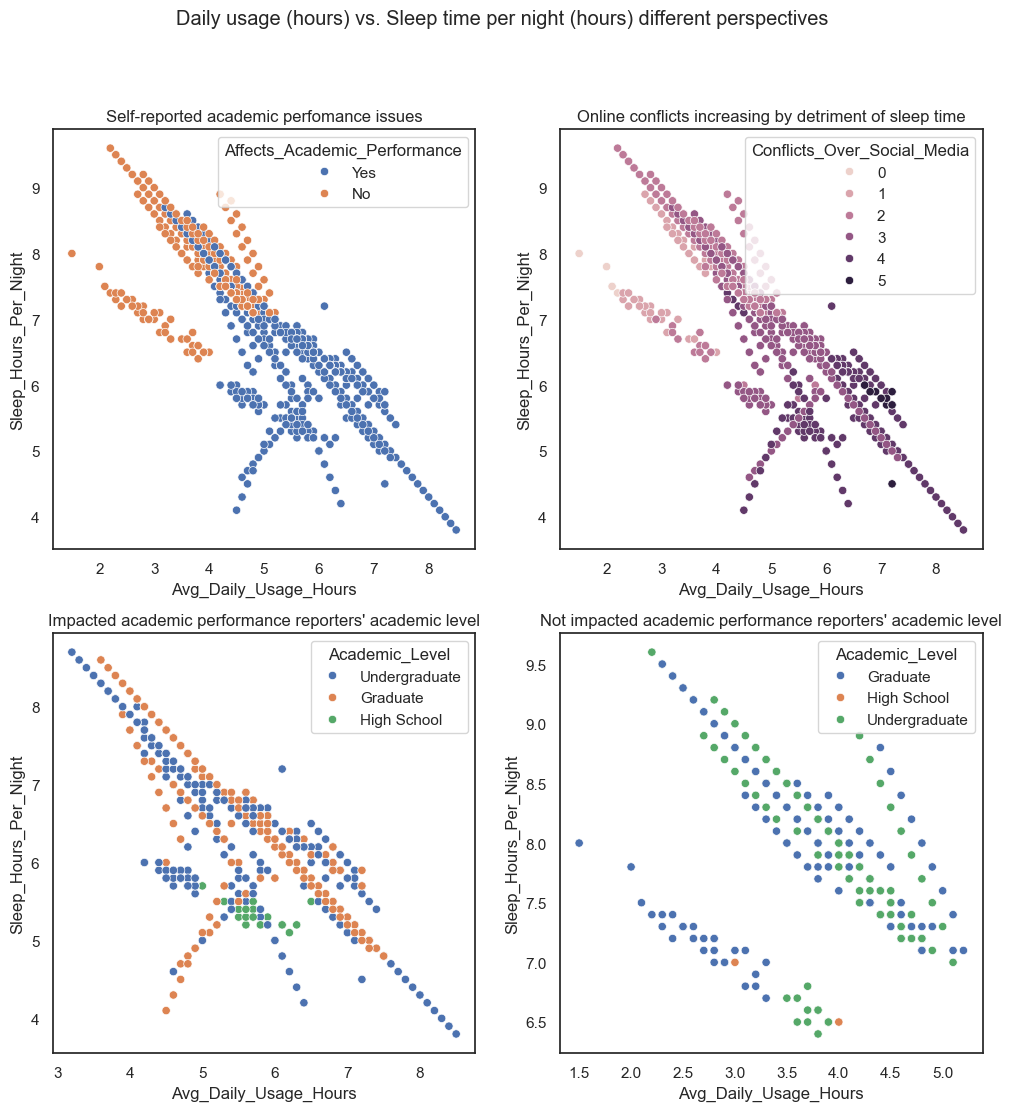

In [165]:
fig, axes = plt.subplots(2, 2, figsize=(12,12))
ax1 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Affects_Academic_Performance',
    ax=axes[0][0]
)
ax1.set_title("Self-reported academic perfomance issues")

ax2 = sns.scatterplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Conflicts_Over_Social_Media',
    ax=axes[0][1]
)
ax2.set_title("Online conflicts increasing by detriment of sleep time")

sub_df_self_reported_academic_performance_problems = df[df['Affects_Academic_Performance'] == 'Yes']
# print(sub_df_self_reported_academic_performance_problems)
ax3 = sns.scatterplot(
    data=sub_df_self_reported_academic_performance_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[1][0]
)
ax3.set_title("Impacted academic performance reporters' academic level")

sub_df_self_reported_academic_performance_no_problems = df[df['Affects_Academic_Performance'] == 'No']
# print(sub_df_self_reported_academic_performance_no_problems)
ax4 = sns.scatterplot(
    data=sub_df_self_reported_academic_performance_no_problems,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    hue='Academic_Level',
    ax=axes[1][1]
)
ax4.set_title("Not impacted academic performance reporters' academic level")
plt.suptitle("Daily usage (hours) vs. Sleep time per night (hours) different perspectives")
plt.show()

<Axes: >

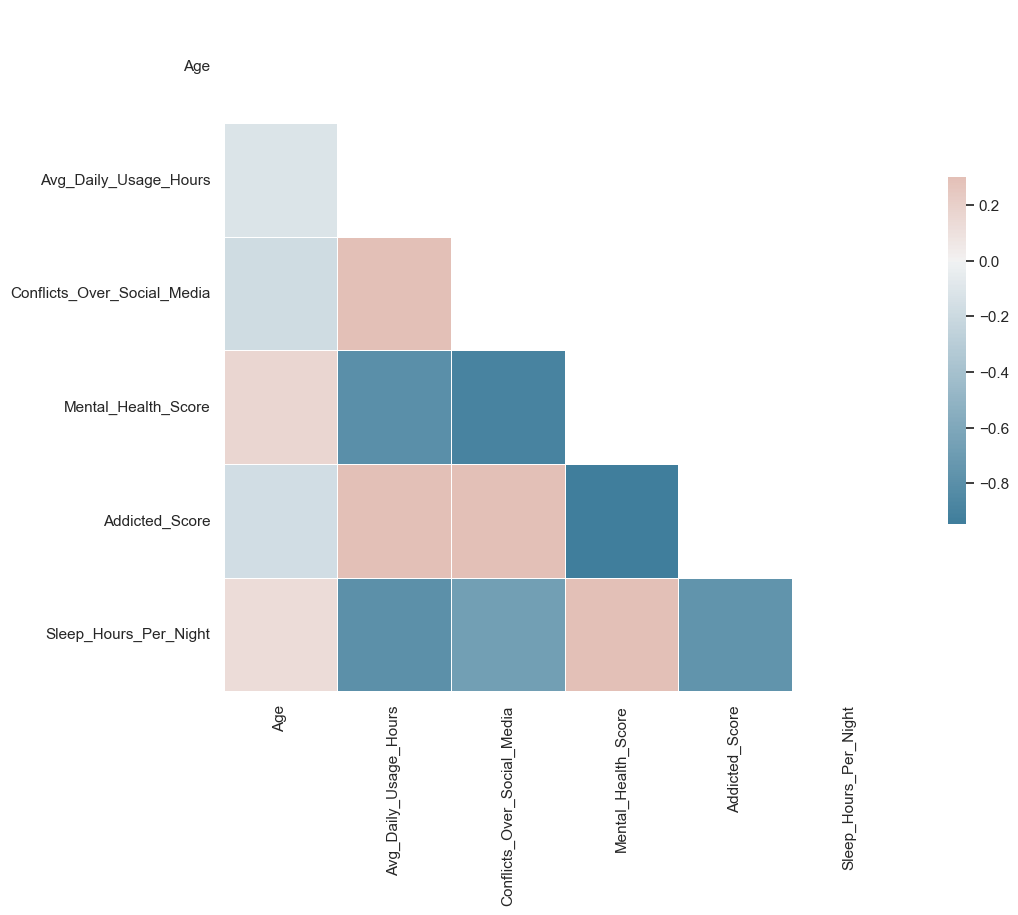

In [76]:
from string import ascii_letters
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the correlation matrix
corr = df[['Age', 'Avg_Daily_Usage_Hours', 'Conflicts_Over_Social_Media', 'Mental_Health_Score', 'Addicted_Score', 'Sleep_Hours_Per_Night']].corr()

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

Gender
Female    353
Male      352
Name: count, dtype: int64


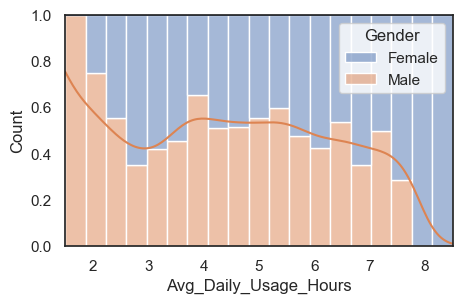

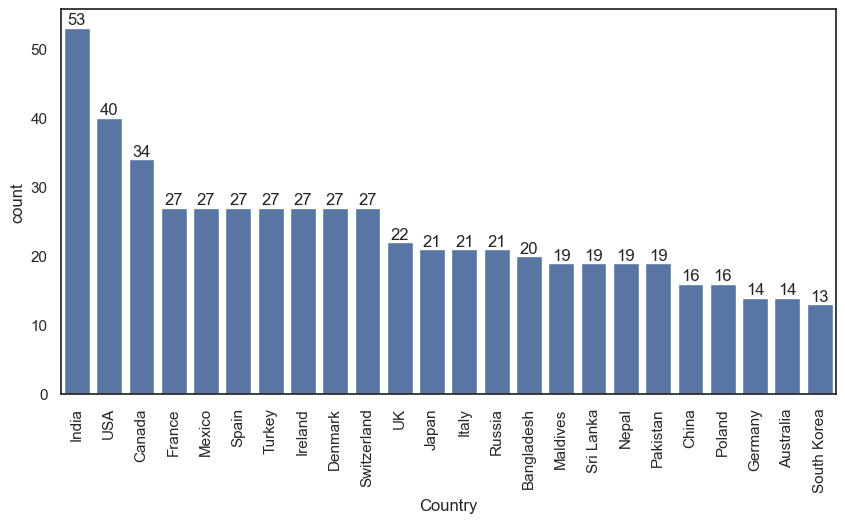

In [77]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df.hist(edgecolor='black', linewidth=1, figsize=(12, 8))
# plt.show()
print(df['Gender'].value_counts())
plt.figure(figsize=(5, 3))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    kde=True, 
    color='skyblue',
    hue='Gender',
    multiple='fill'
)
plt.show()

n
top_n = df['Country'].value_counts()[df['Country'].value_counts() > 10].index #more than 10 records for simplicity
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=df, 
    x='Country',
    order=top_n
)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=90)
plt.show()

Gender
Female    353
Male      352
Name: count, dtype: int64


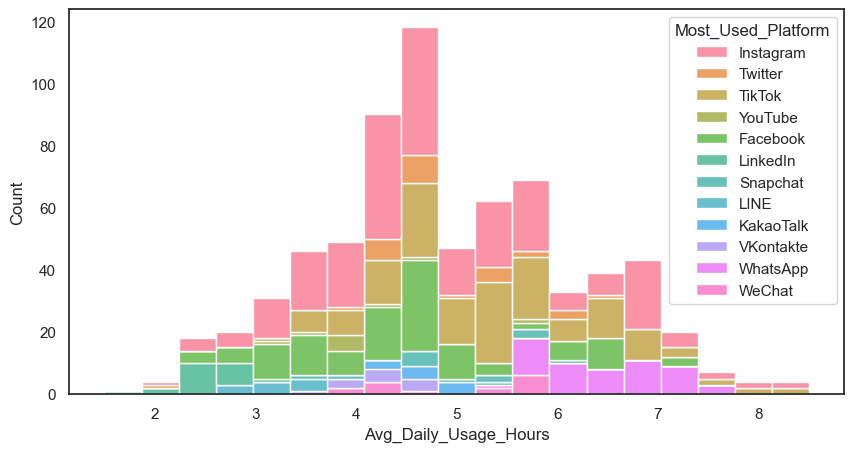

In [78]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# df.hist(edgecolor='black', linewidth=1, figsize=(12, 8))
# plt.show()
print(df['Gender'].value_counts())
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df, 
    x='Avg_Daily_Usage_Hours', 
    color='skyblue',
    hue="Most_Used_Platform",
    multiple="stack"
)
plt.show()

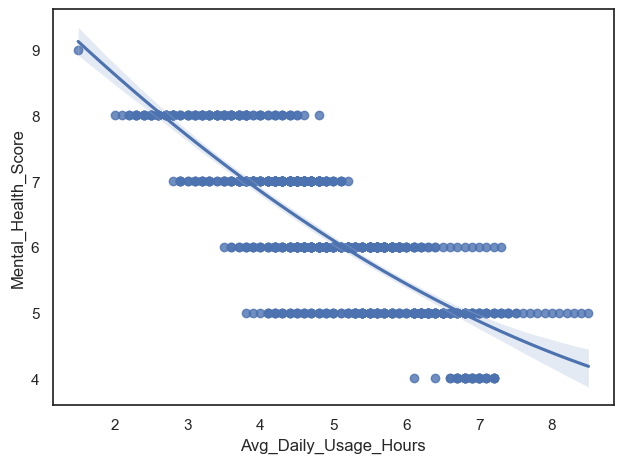

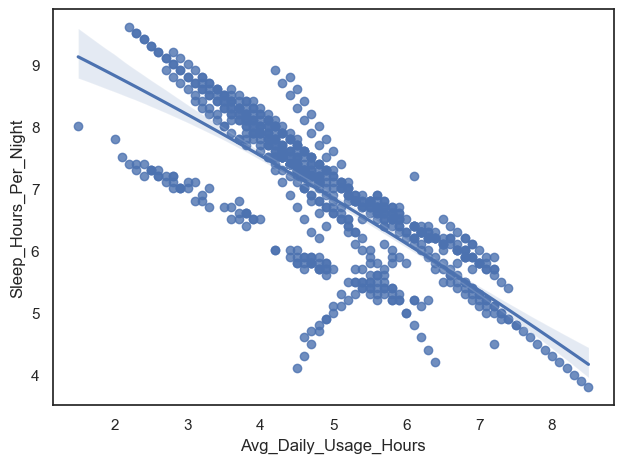

In [79]:
ax = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Mental_Health_Score',
    order=2
)
ax.tick_params(axis='x')
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5,
    title='Gender', frameon=True
)
plt.tight_layout()
plt.show()

ax = sns.regplot(
    data=df,
    x='Avg_Daily_Usage_Hours',
    y='Sleep_Hours_Per_Night',
    order=2,
)
ax.tick_params(axis='x')
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5,
    title='Gender', frameon=True
)
plt.tight_layout()
plt.show()

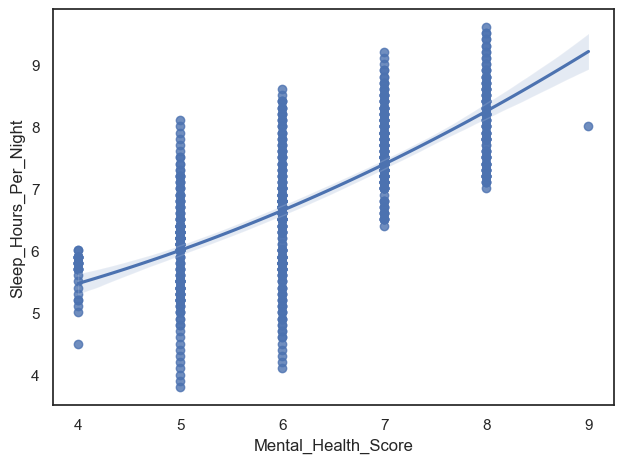

In [80]:
ax = sns.regplot(
    data=df_sorted,
    x='Mental_Health_Score',
    y='Sleep_Hours_Per_Night',
    order=2,

)
ax.tick_params(axis='x')
sns.move_legend(
    ax2, "lower center",
    bbox_to_anchor=(.5, 1), ncol=5,
    title='Gender', frameon=True
)
plt.tight_layout()
plt.show()